experiments\baseline_biobertpt\metrics.jsonl
PR metrics:
Macro PR-AUC: 0.096 ± 0.214
Micro PR-AUC: 0.112 ± 0.255


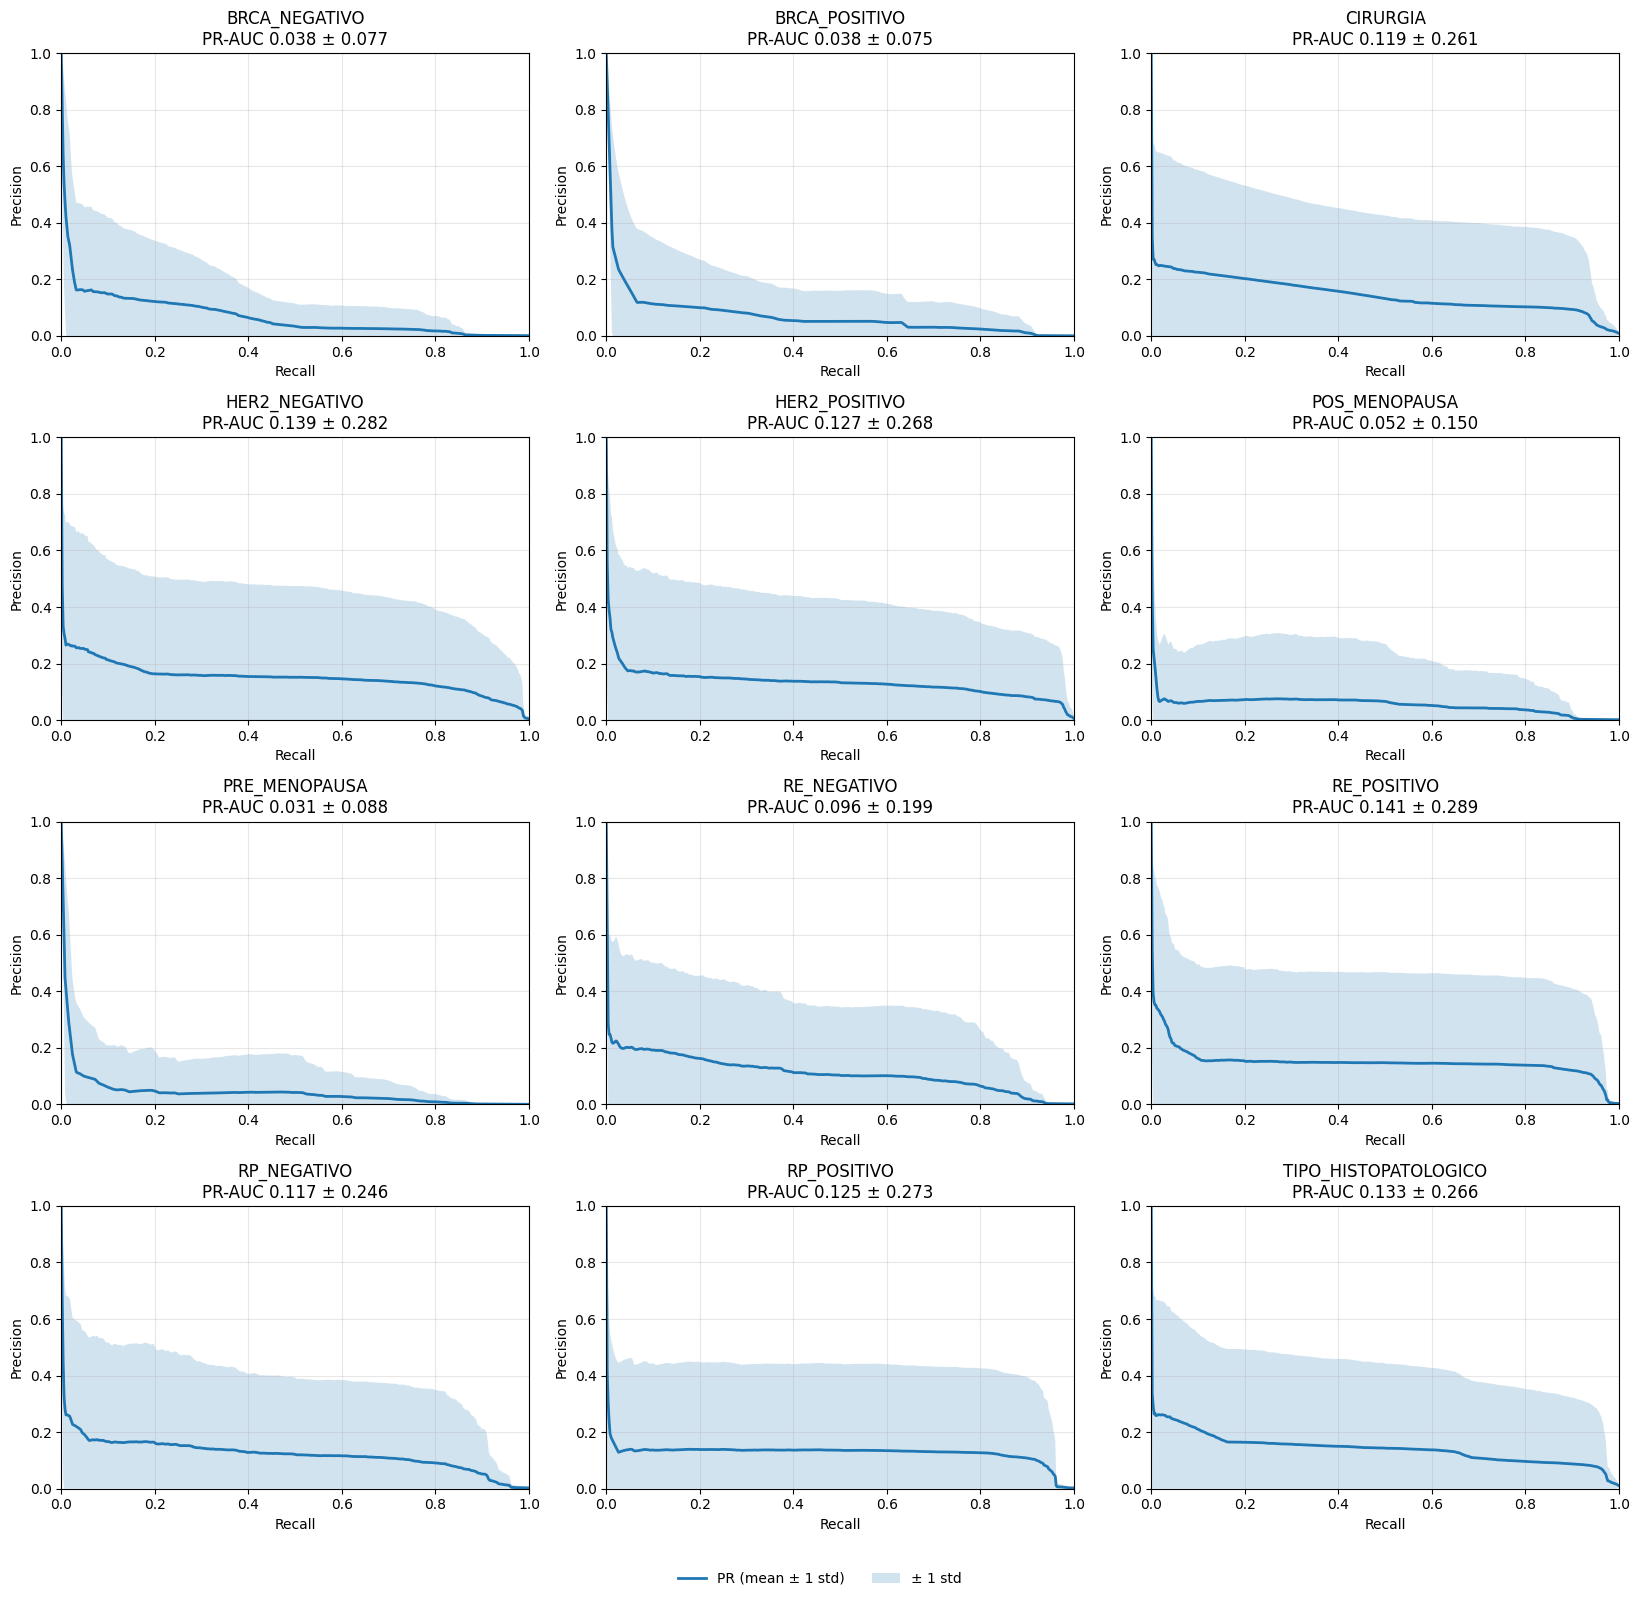

experiments\baseline_mmbert\metrics.jsonl
PR metrics:
Macro PR-AUC: 0.659 ± 0.041
Micro PR-AUC: 0.714 ± 0.065


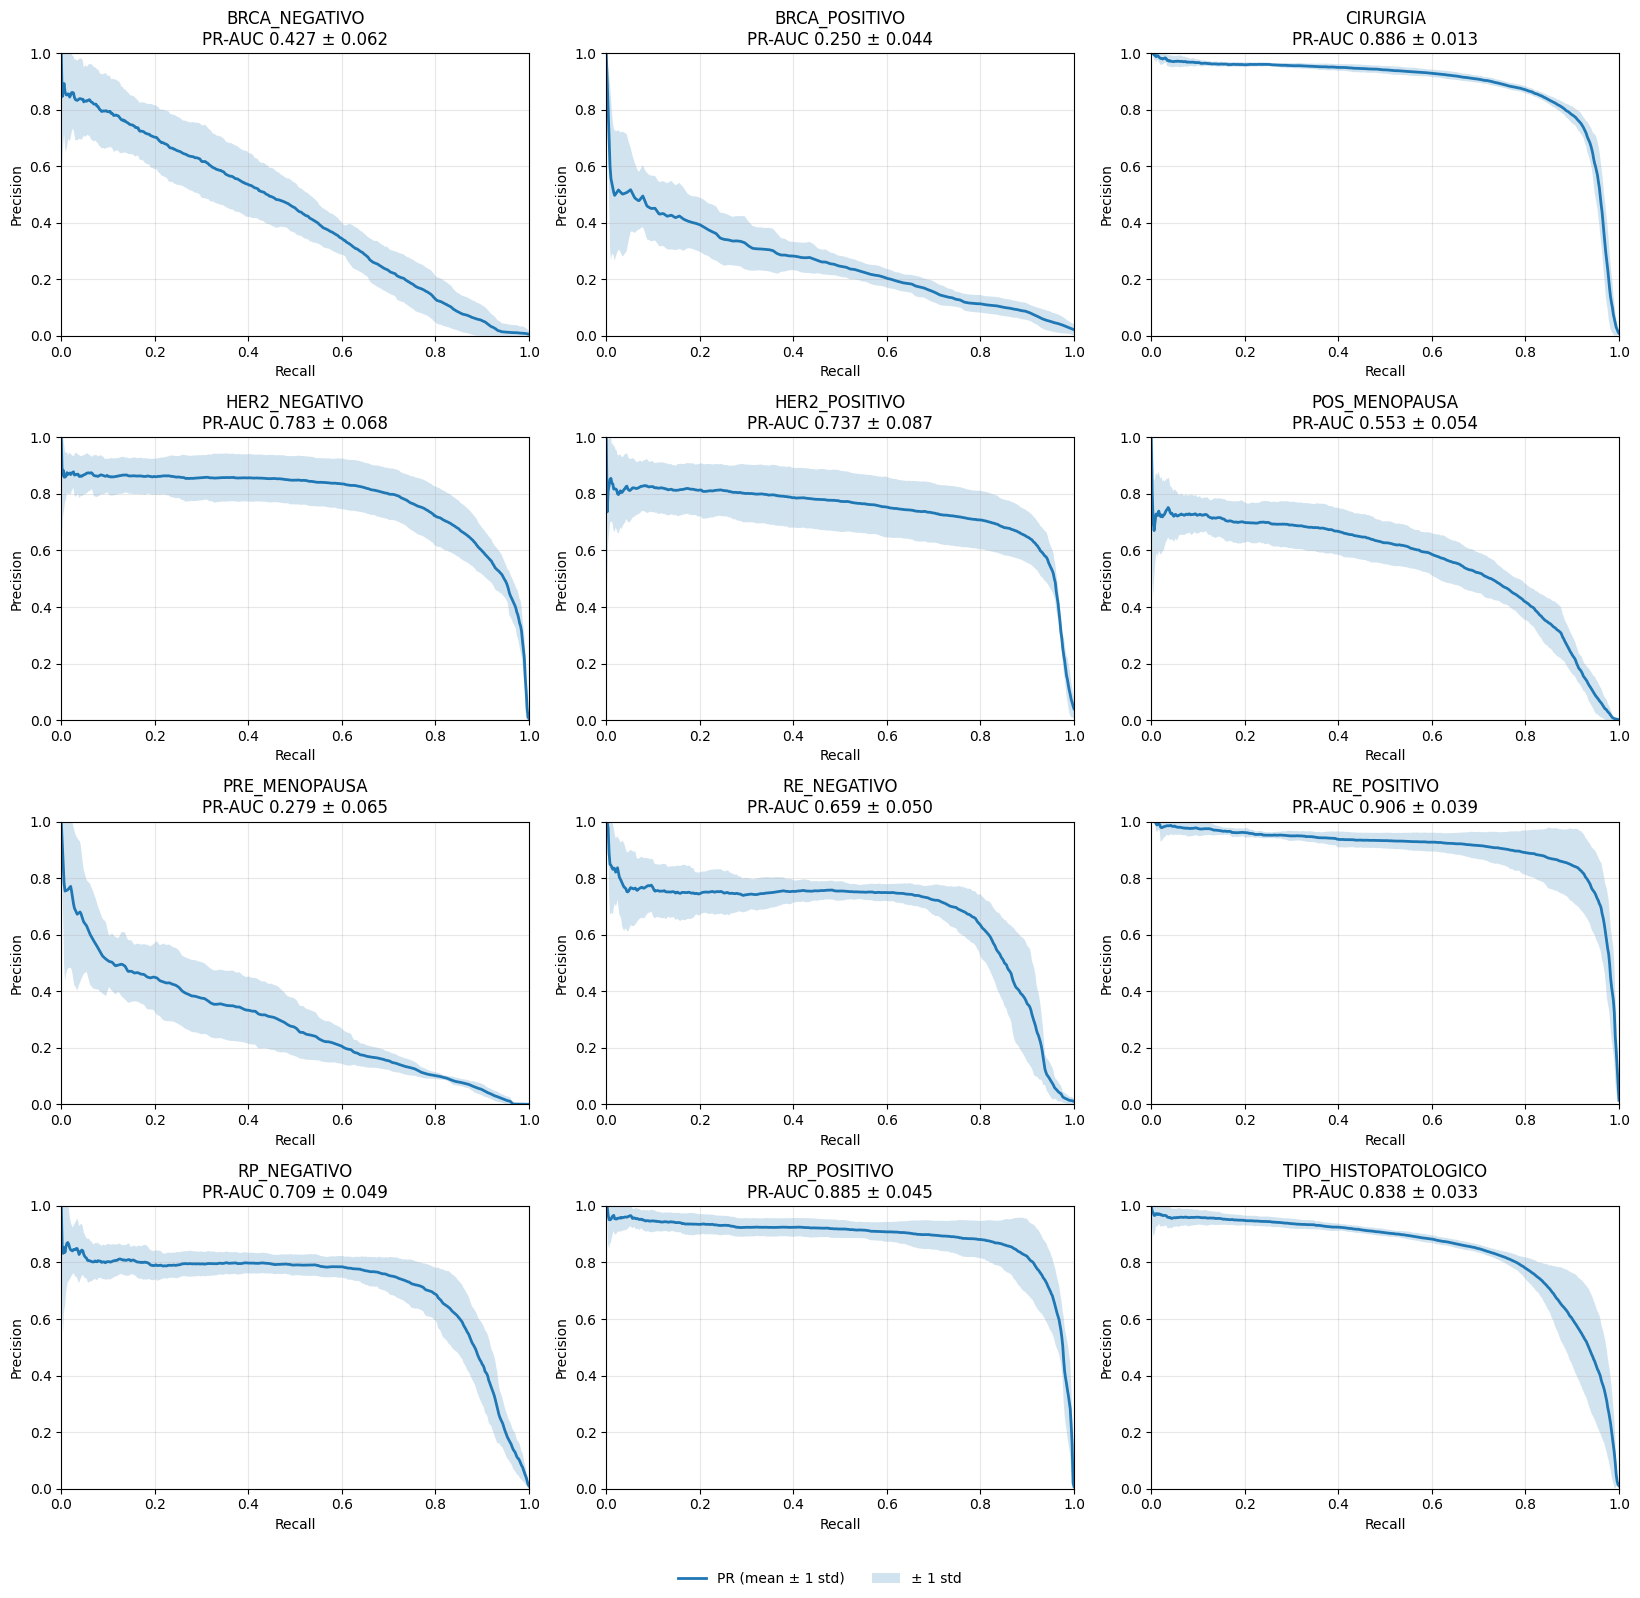

experiments\baseline_modernbert\metrics.jsonl
PR metrics:
Macro PR-AUC: 0.670 ± 0.043
Micro PR-AUC: 0.742 ± 0.061


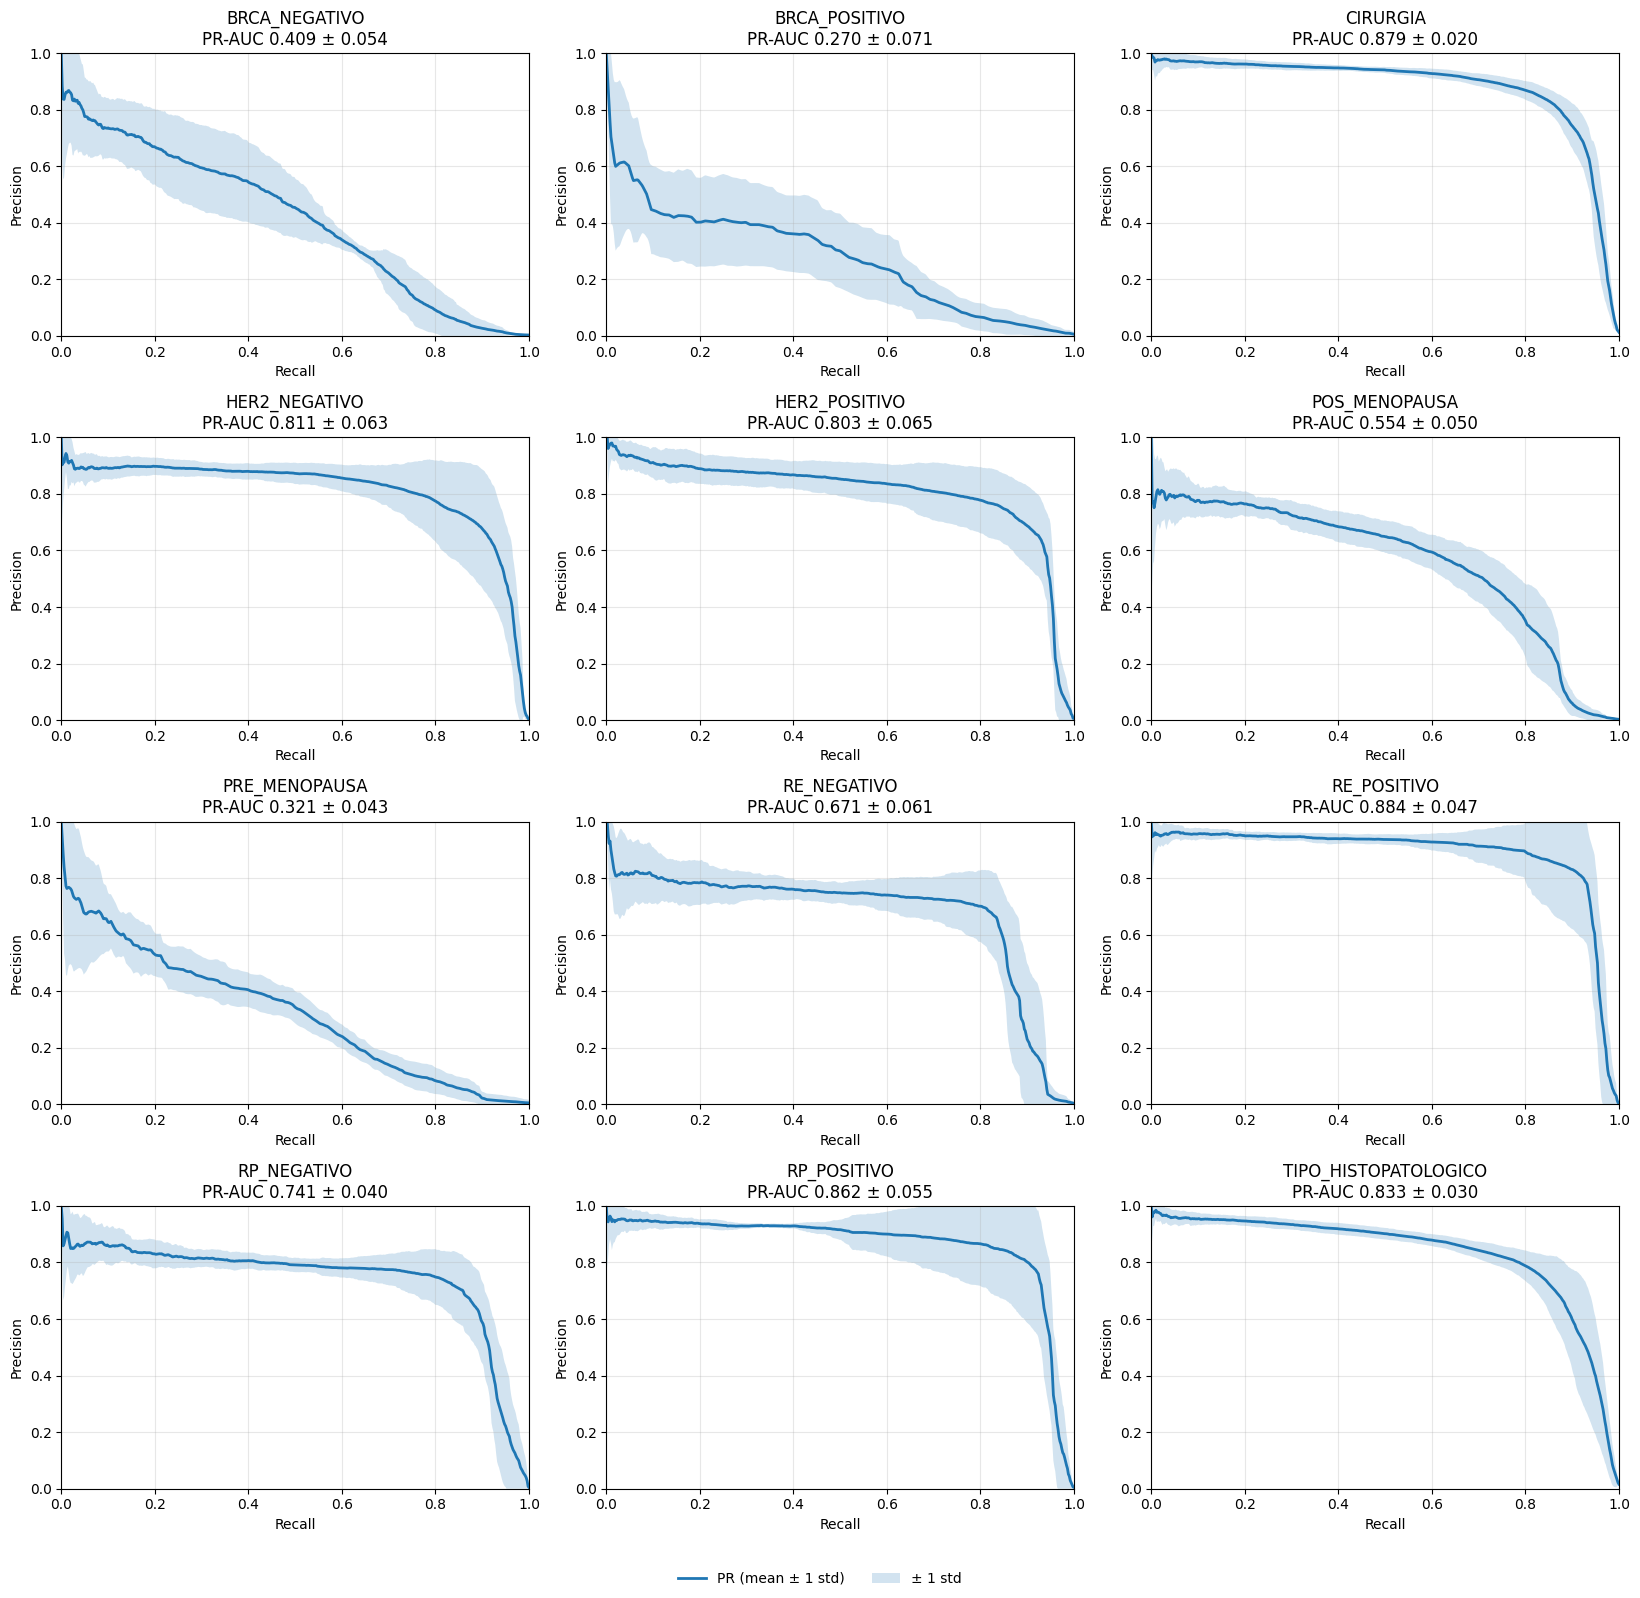

experiments\exp_1_mecla_biobertpt\metrics.jsonl
PR metrics:
Macro PR-AUC: 0.004 ± 0.001
Micro PR-AUC: 0.006 ± 0.001


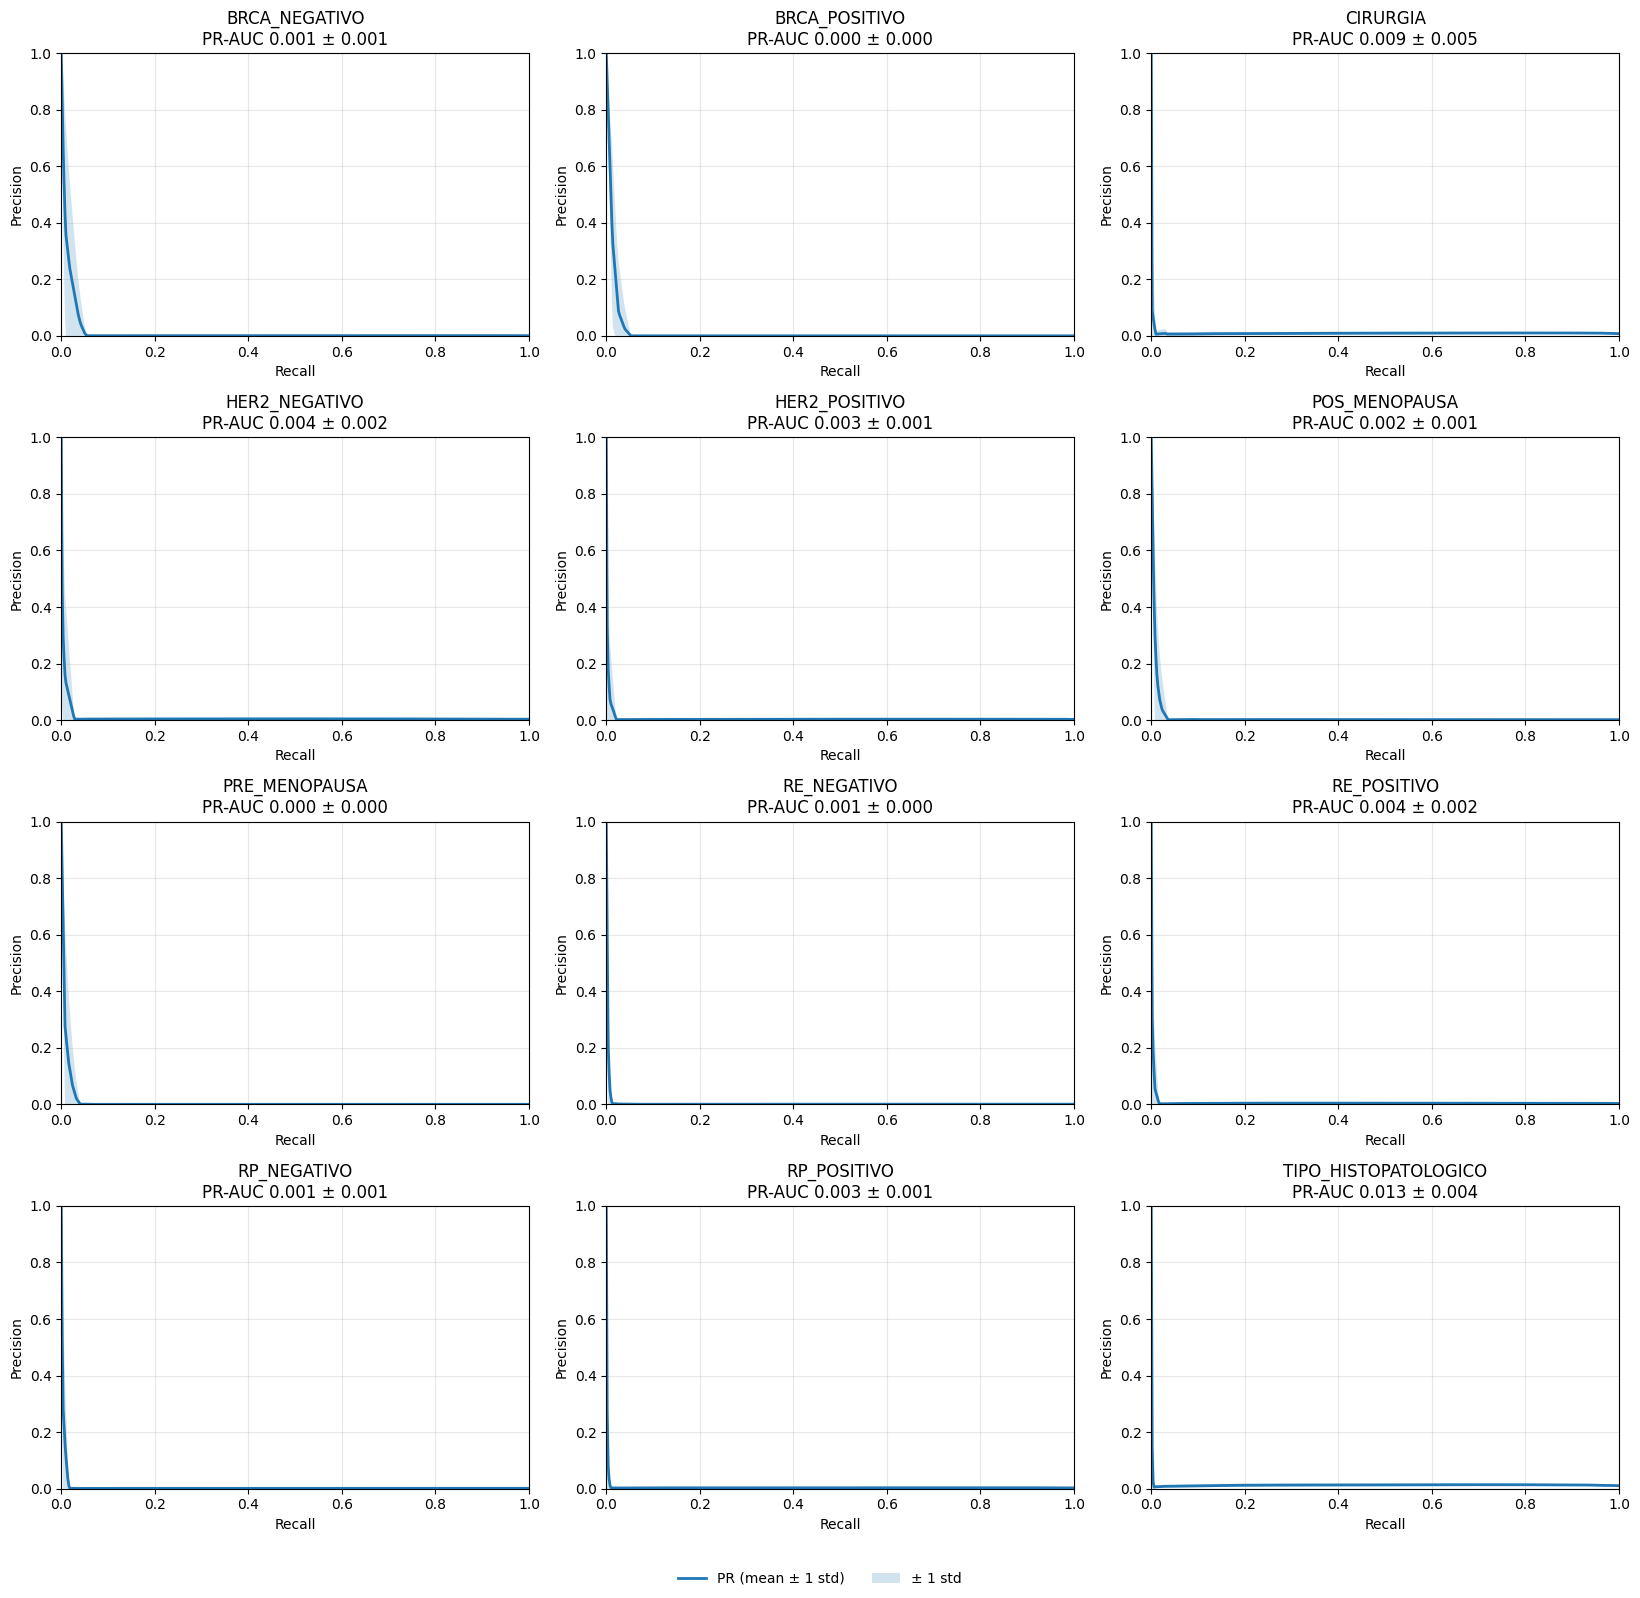

experiments\exp_1_mecla_mmbert\metrics.jsonl
PR metrics:
Macro PR-AUC: 0.705 ± 0.025
Micro PR-AUC: 0.764 ± 0.041


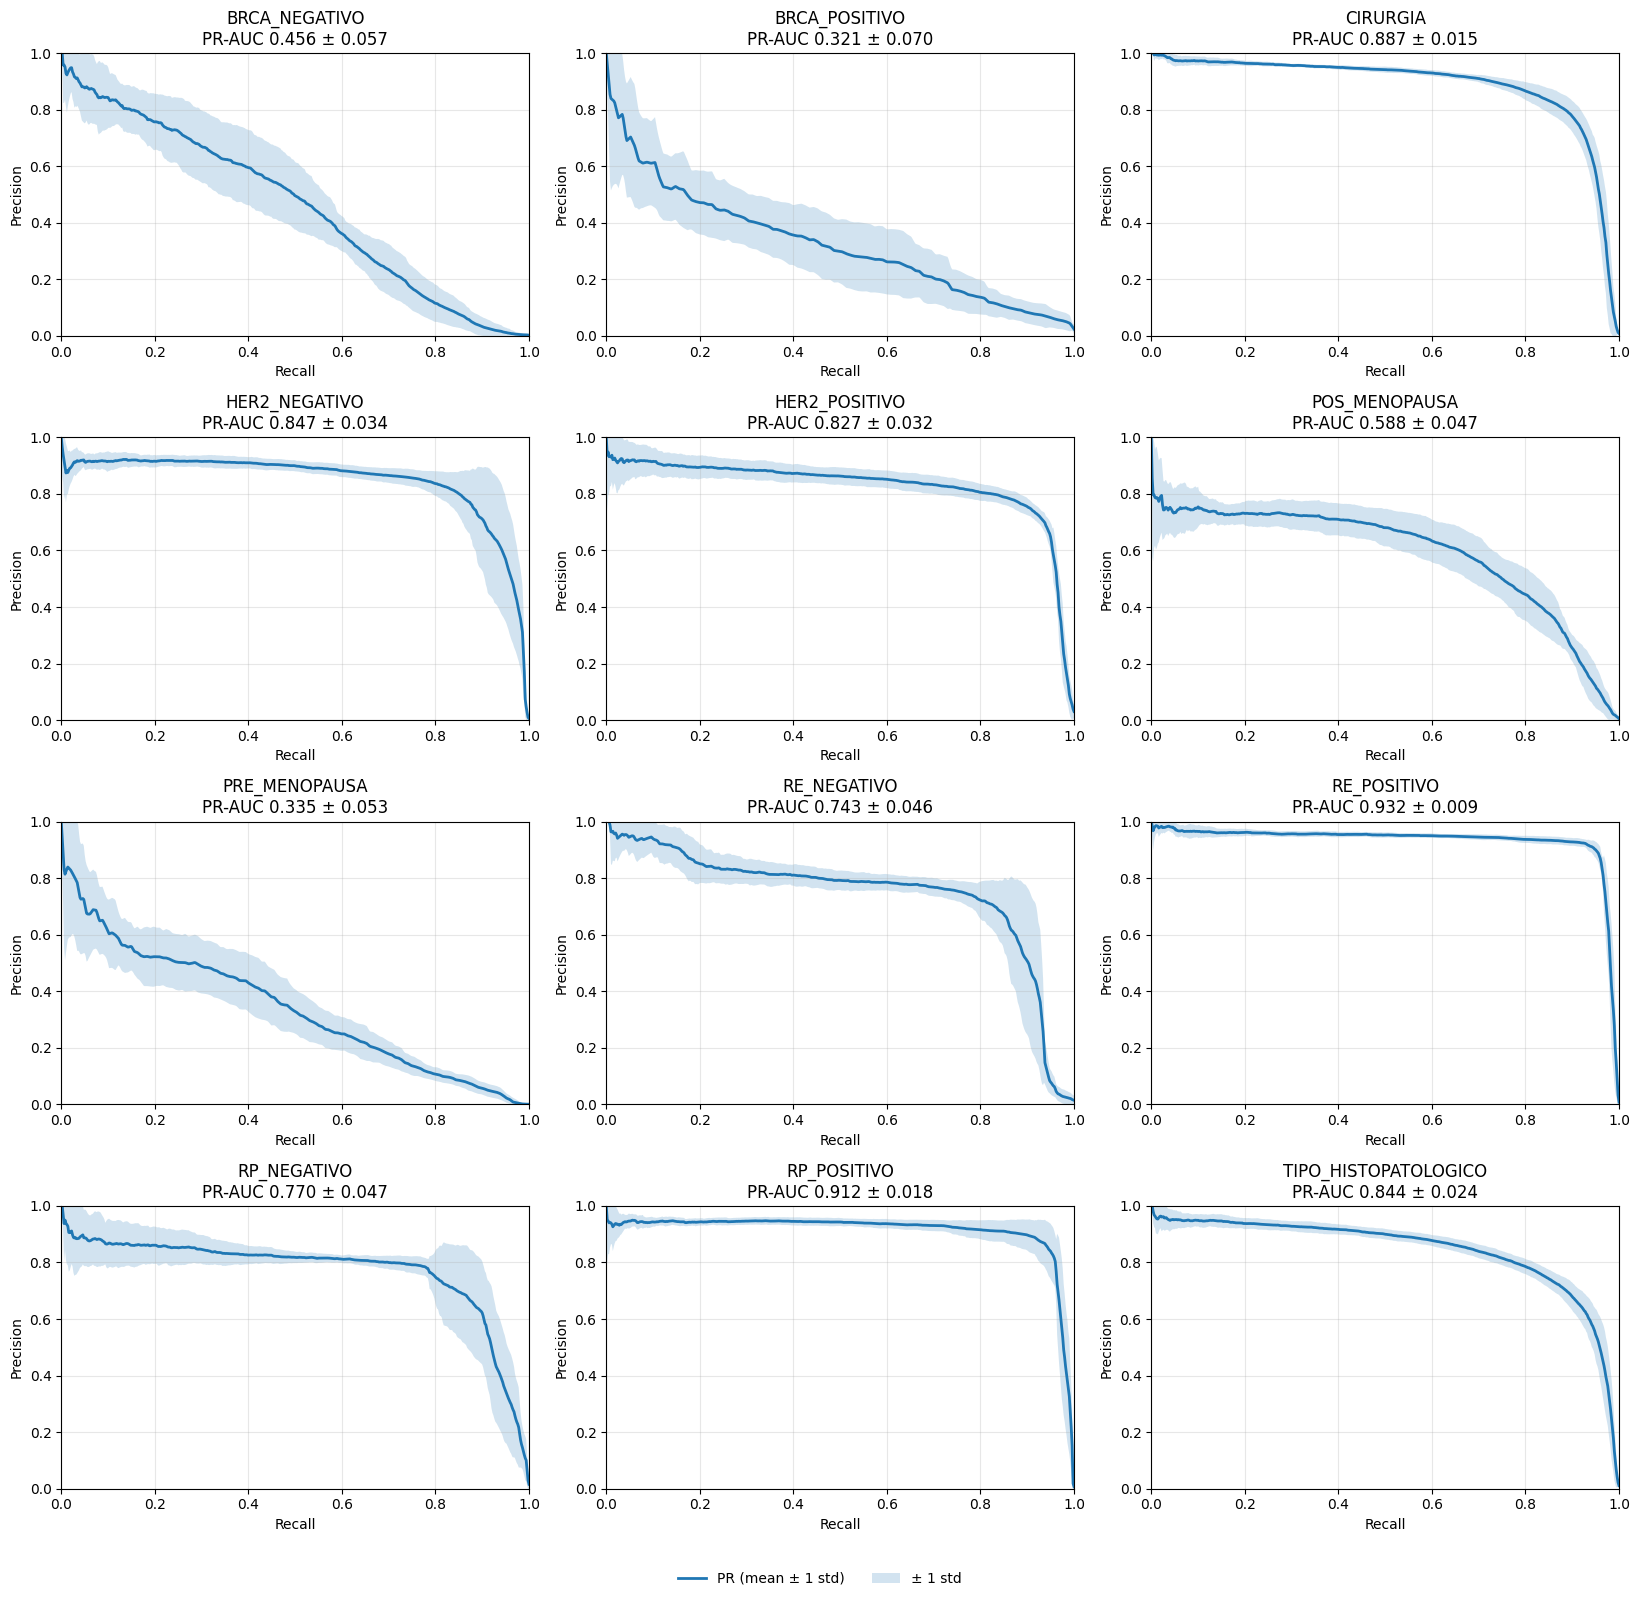

experiments\exp_1_mecla_modernbert\metrics.jsonl
PR metrics:
Macro PR-AUC: 0.654 ± 0.064
Micro PR-AUC: 0.720 ± 0.052


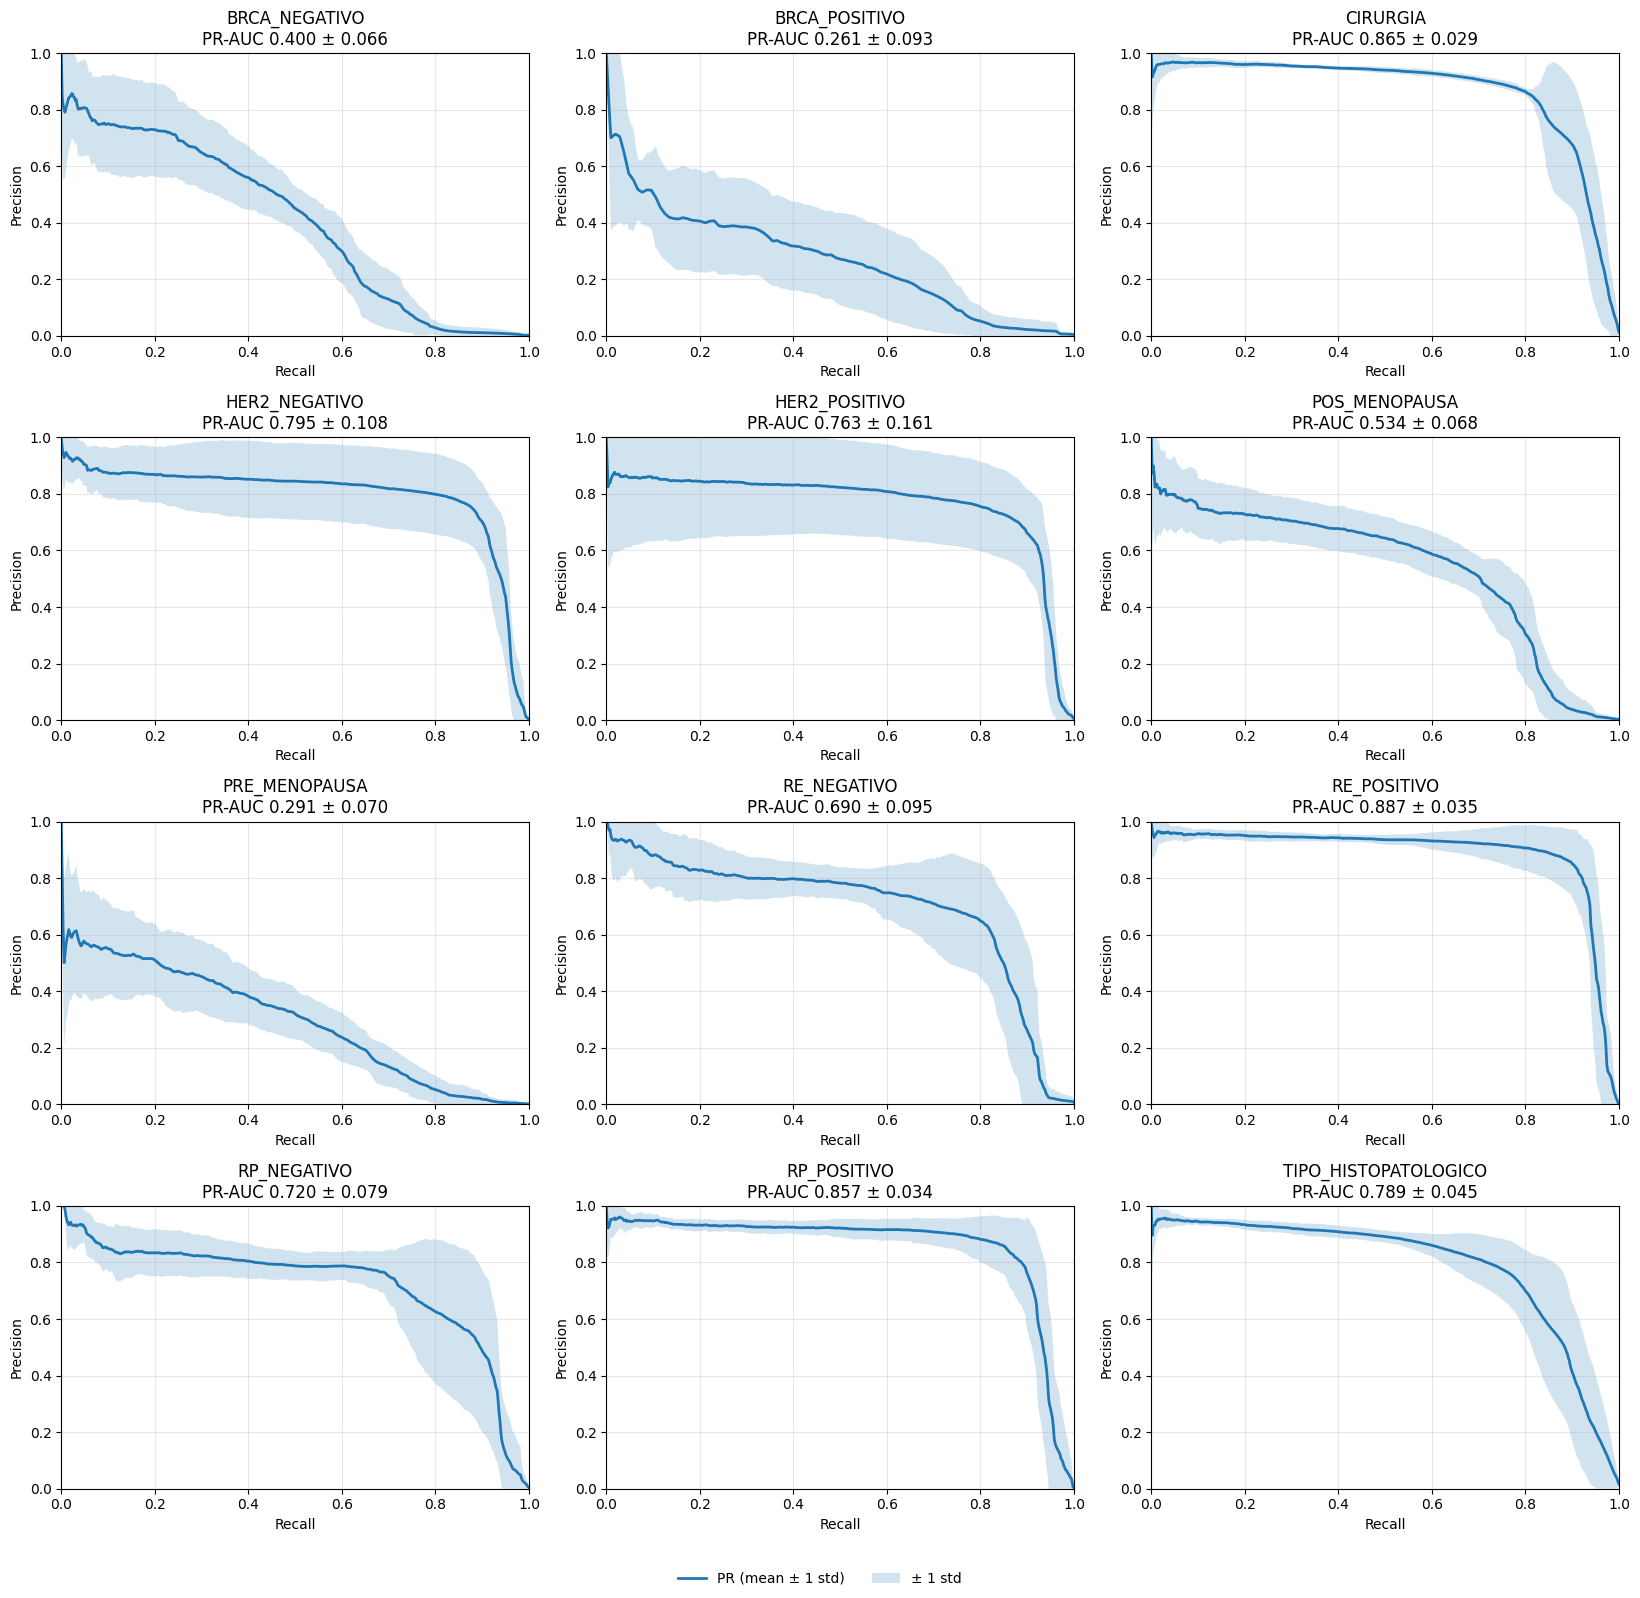

experiments\exp_2_mecla_biobertpt\metrics.jsonl
PR metrics:
Macro PR-AUC: 0.005 ± 0.004
Micro PR-AUC: 0.006 ± 0.002


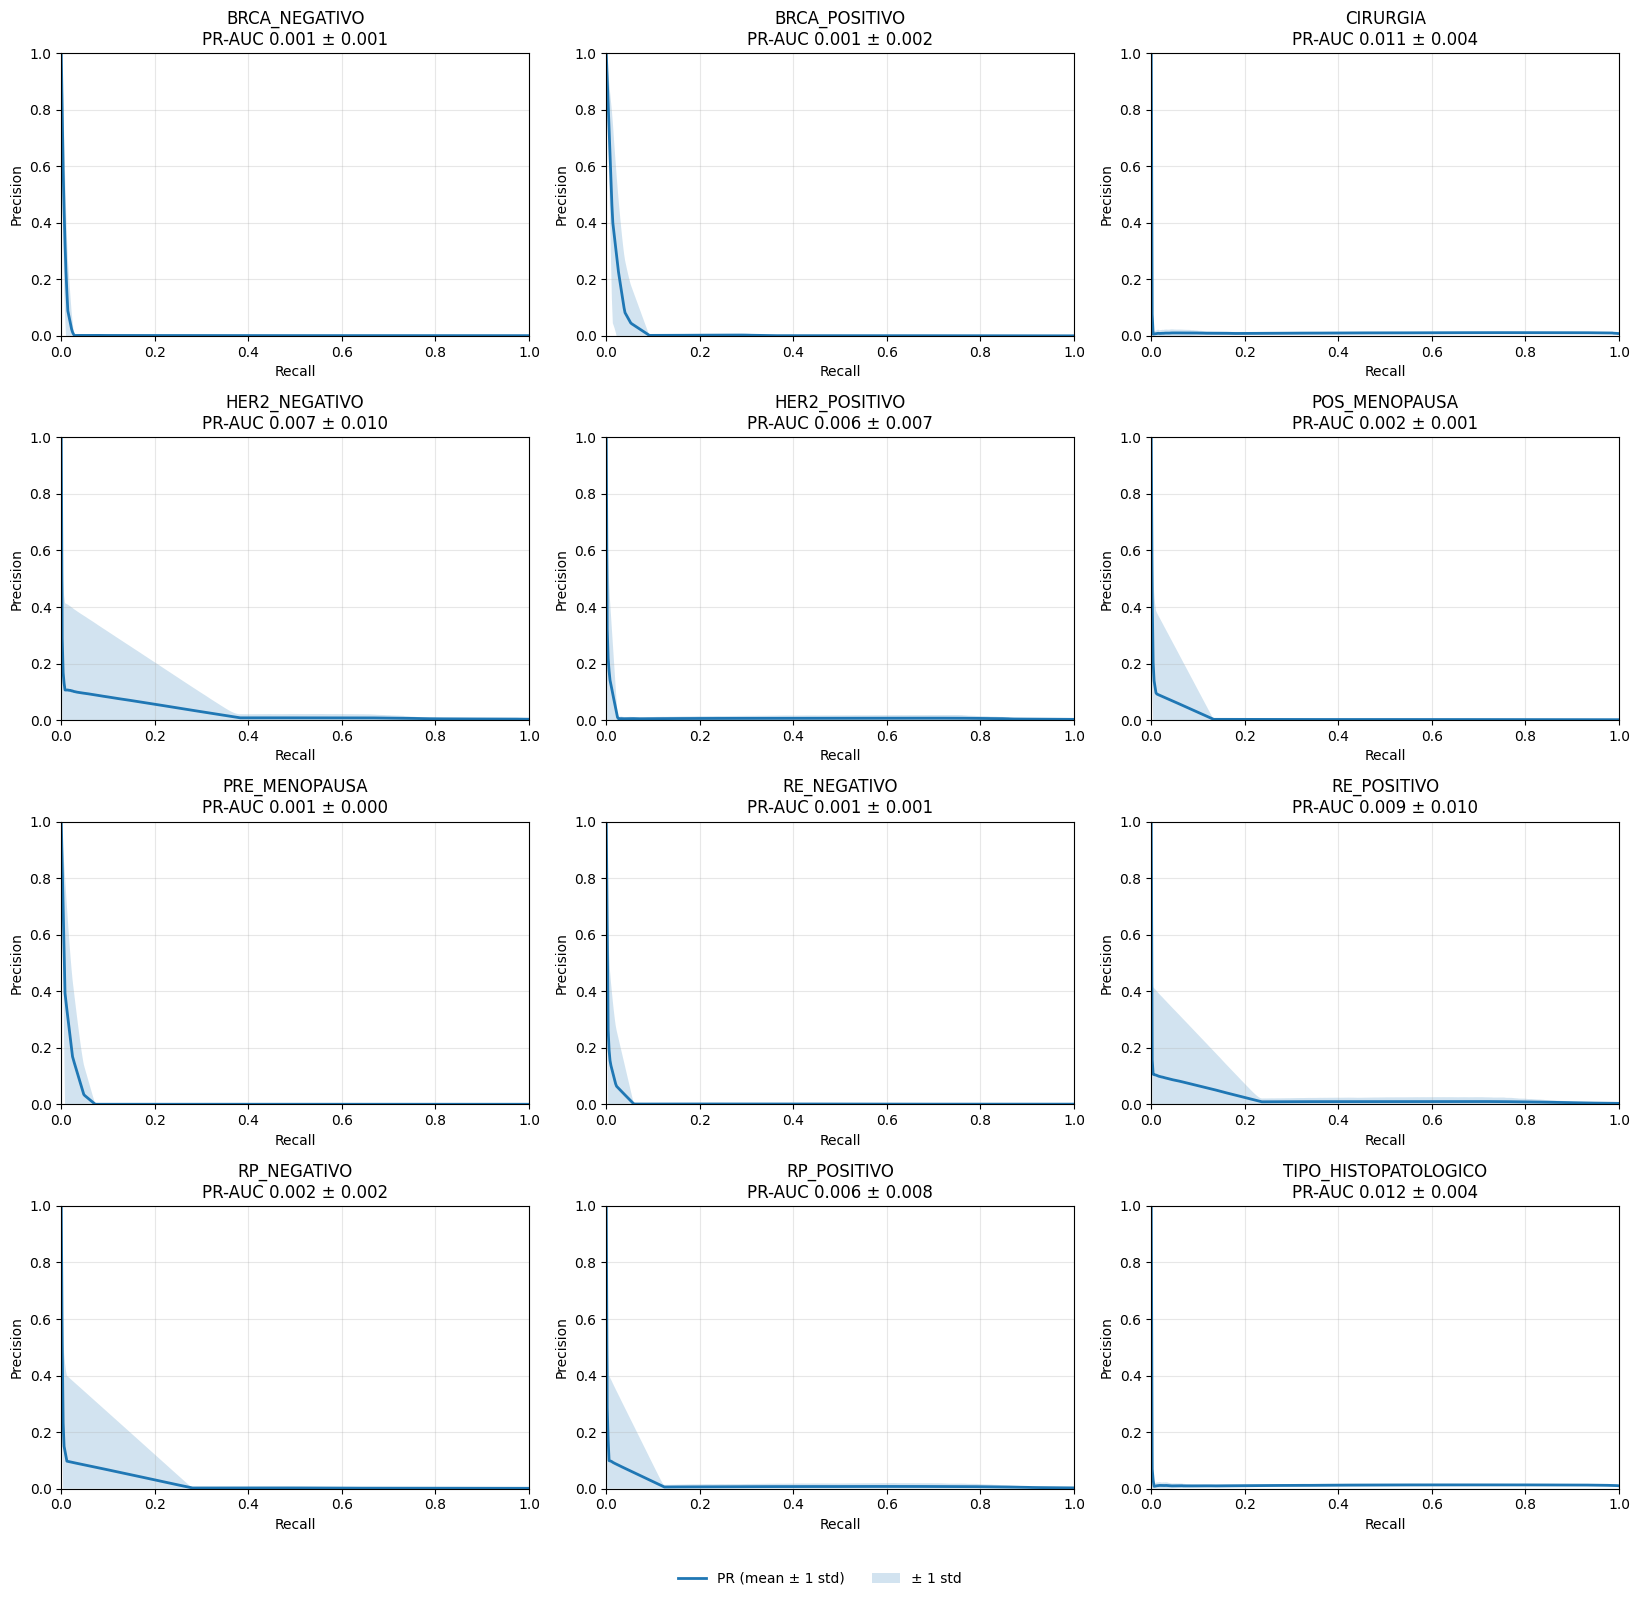

experiments\exp_2_mecla_mmbert\metrics.jsonl
PR metrics:
Macro PR-AUC: 0.704 ± 0.022
Micro PR-AUC: 0.752 ± 0.034


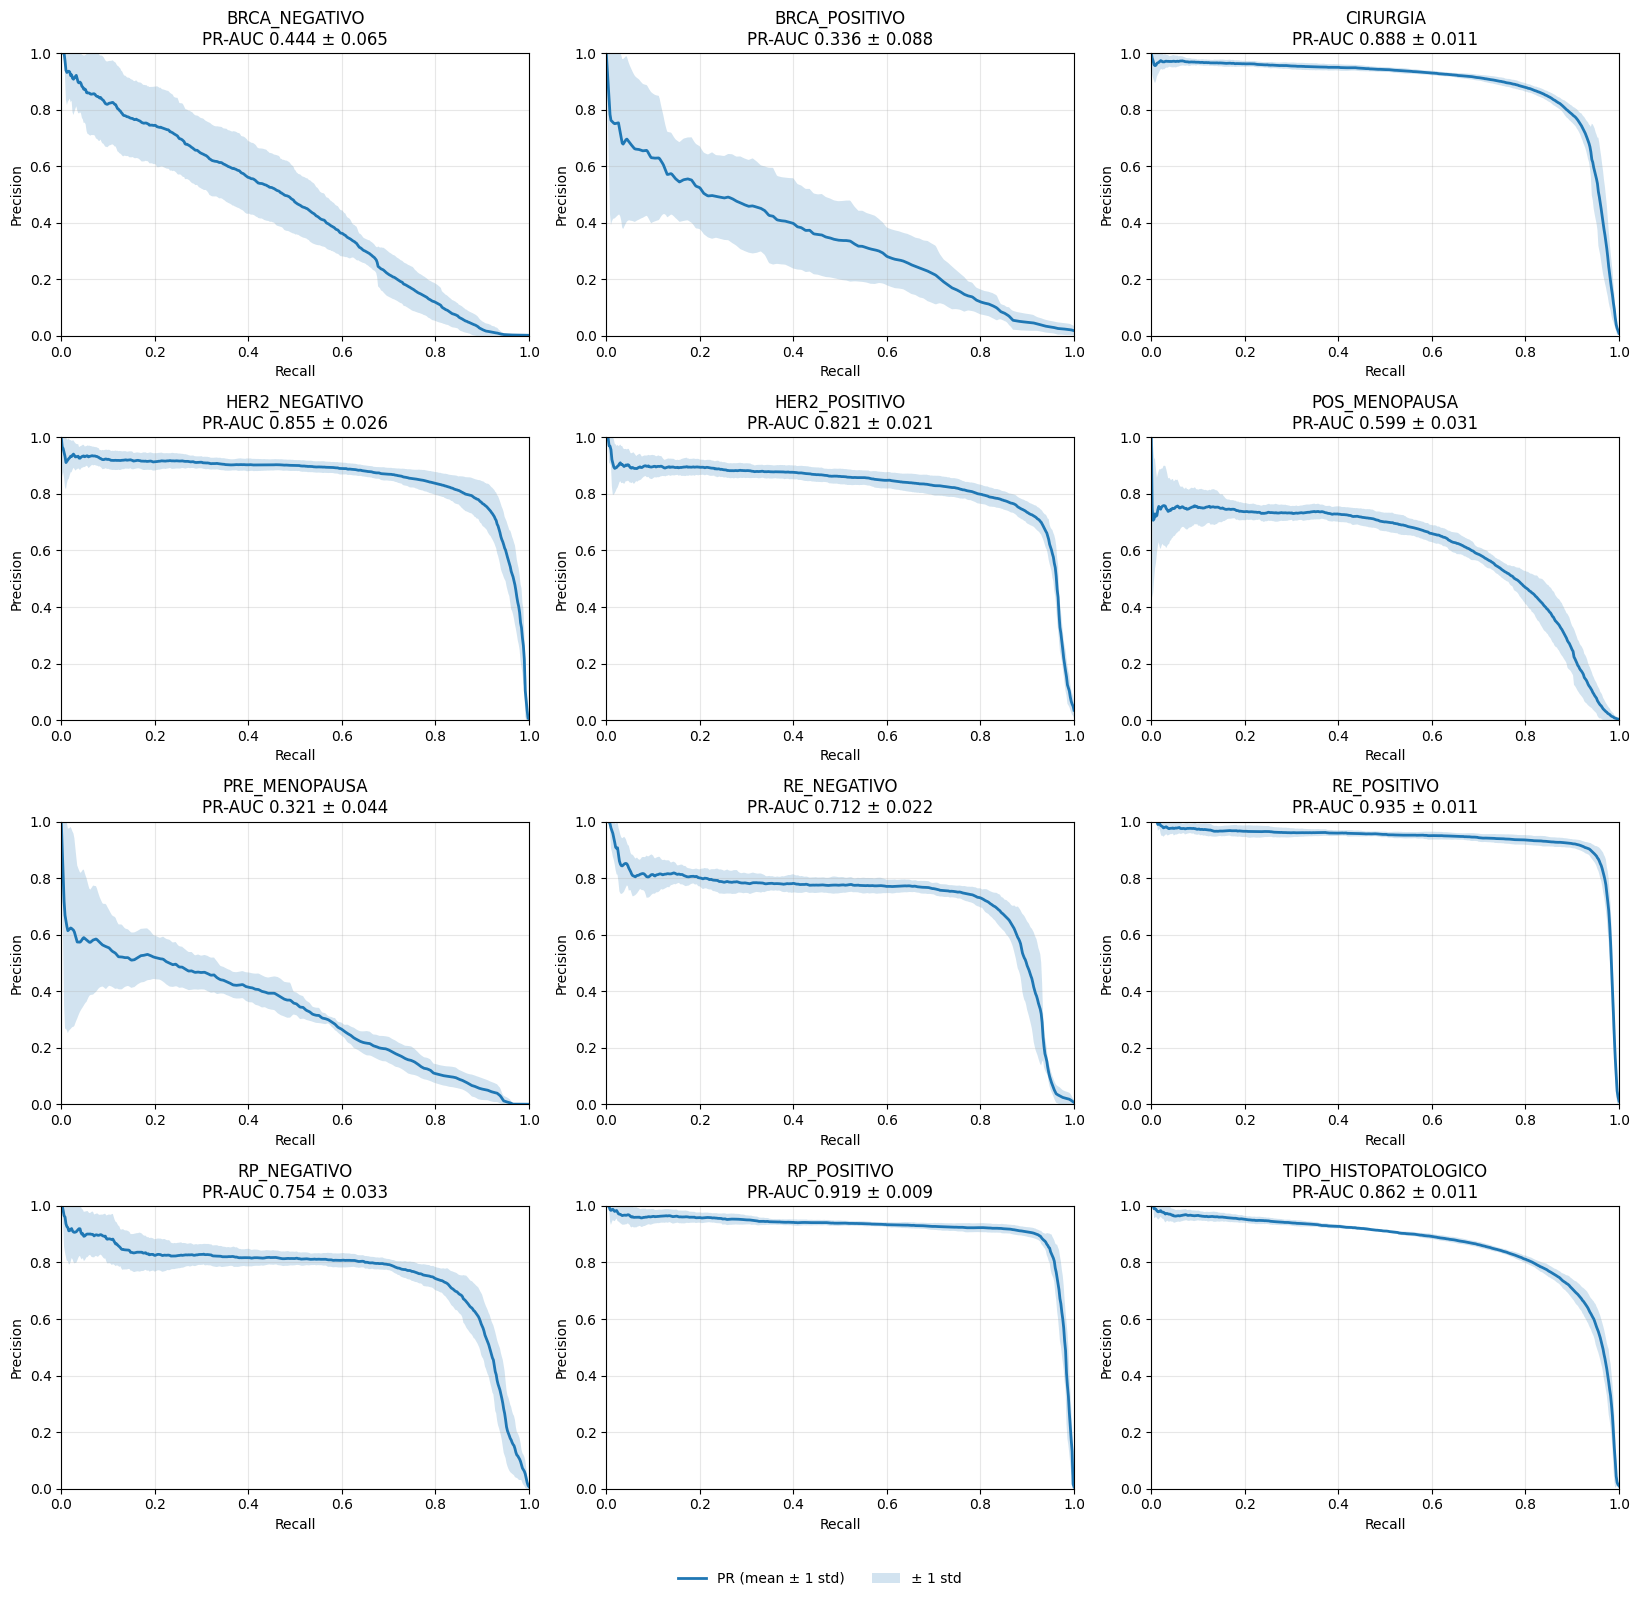

experiments\exp_2_mecla_modernbert\metrics.jsonl
PR metrics:
Macro PR-AUC: 0.661 ± 0.025
Micro PR-AUC: 0.721 ± 0.046


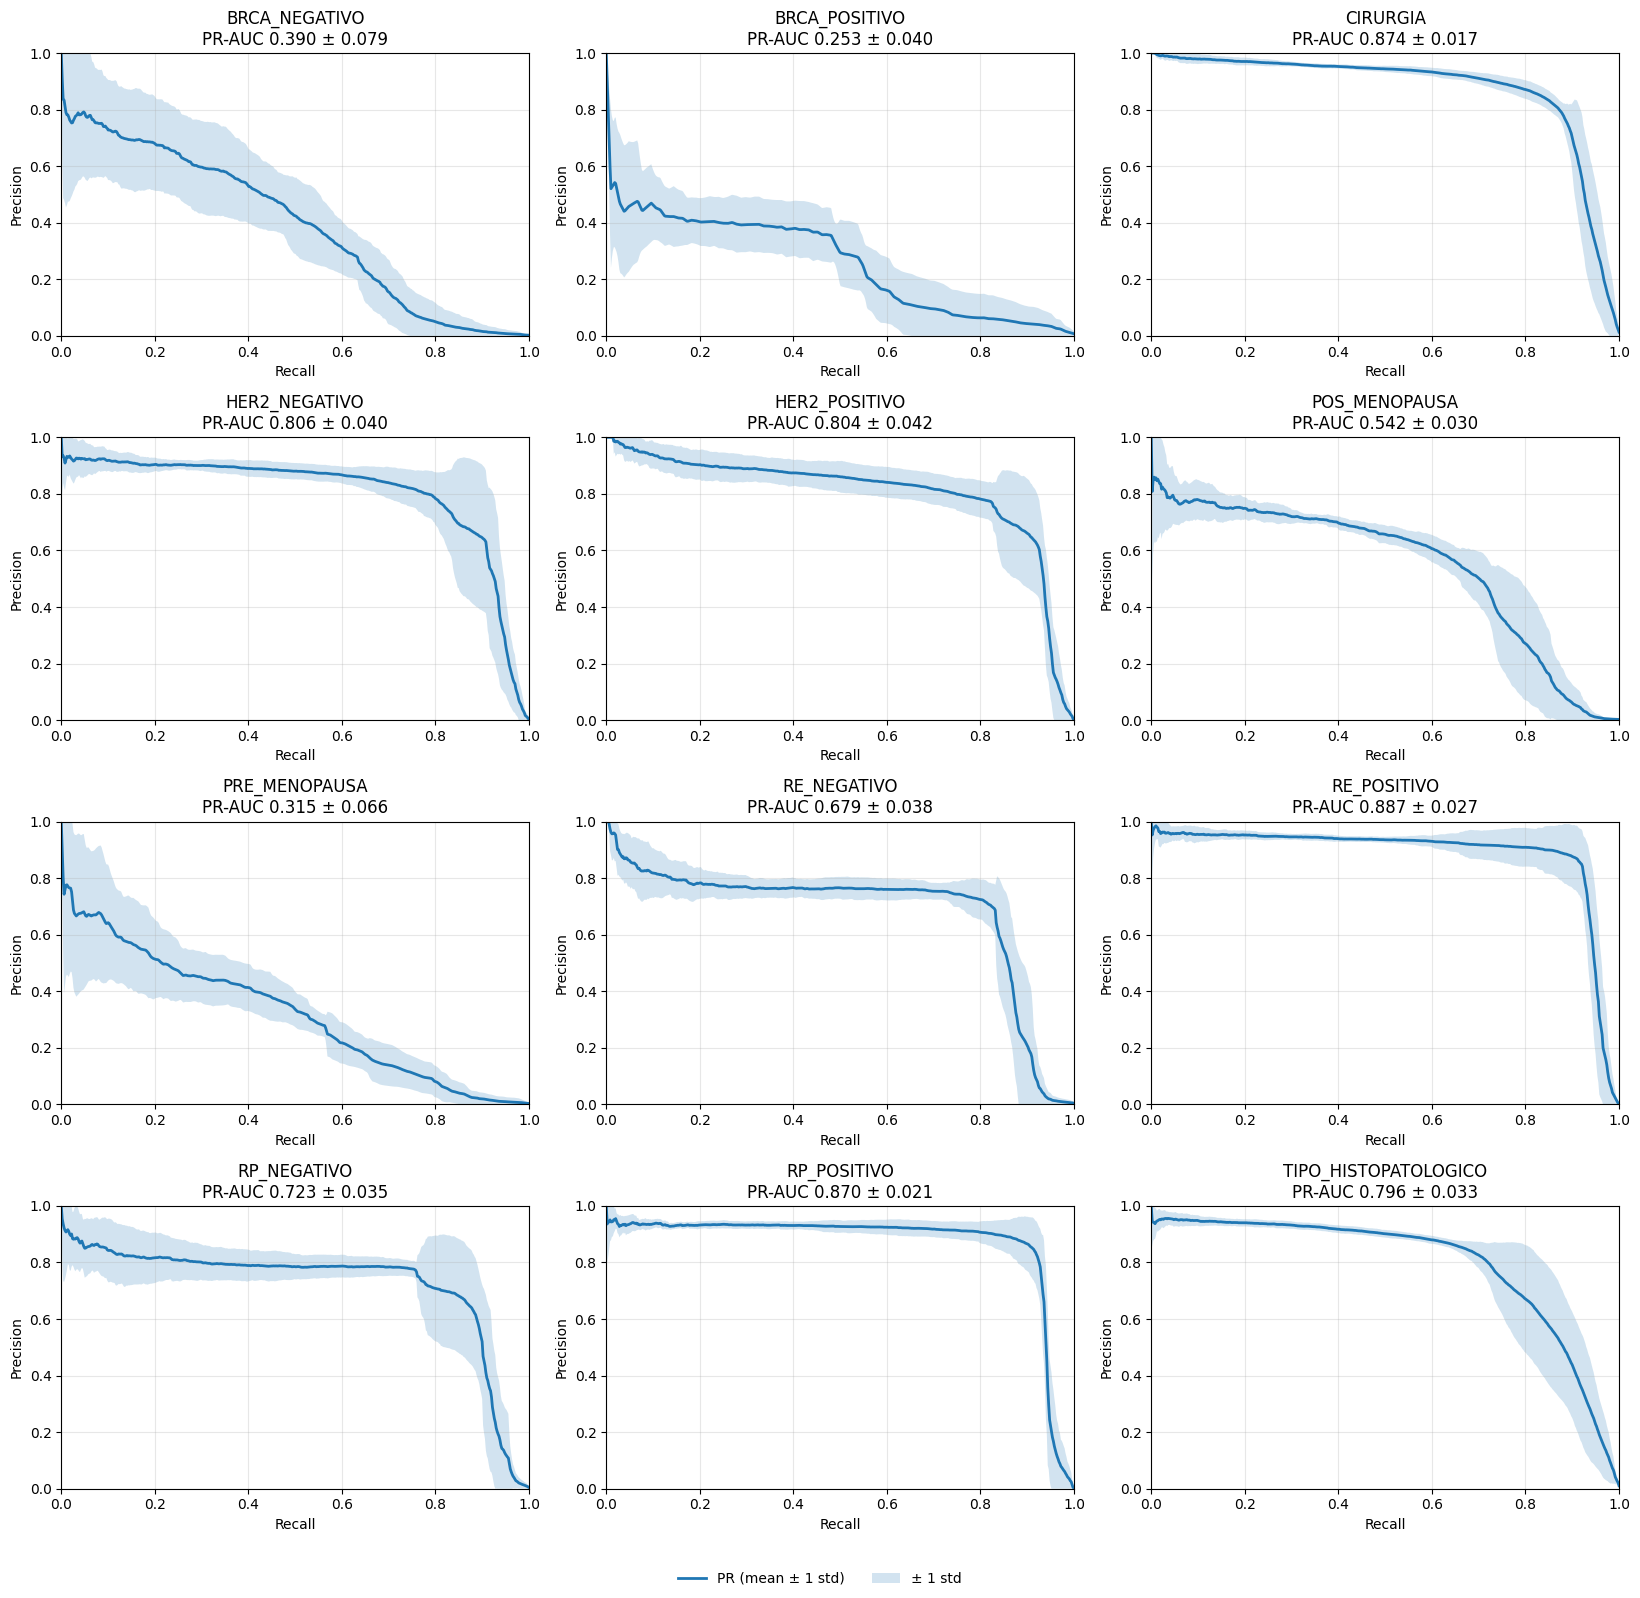

In [1]:
import pandas as pd
import jsonlines
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt


def _compute_pr_mean_std(
    precisions_list: list[list[float]],
    recalls_list: list[list[float]],
    n_grid: int = 500,
    clip_to_unit: bool = True,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute mean Precision-Recall curve with ±1 std bands on a common recall grid.

    Returns
    -------
    recall_grid : np.ndarray, shape (n_grid,)
    mean_p      : np.ndarray, shape (n_grid,)
    lower       : np.ndarray, shape (n_grid,)
    upper       : np.ndarray, shape (n_grid,)
    """
    if len(precisions_list) != len(recalls_list):
        raise ValueError("Mismatch runs count")

    recall_grid = np.linspace(0.0, 1.0, n_grid)
    interp_precisions: list[np.ndarray] = []

    for p, r in zip(precisions_list, recalls_list):
        p = np.asarray(p, dtype=float)
        r = np.asarray(r, dtype=float)

        # 1) sort by recall
        order = np.argsort(r)
        r = r[order]
        p = p[order]

        # 2) collapse duplicate recalls by max precision
        uniq_r, inv = np.unique(r, return_inverse=True)
        max_p = np.full_like(uniq_r, -np.inf, dtype=float)
        for i, idx in enumerate(inv):
            max_p[idx] = max(max_p[idx], p[i])
        r, p = uniq_r, max_p

        # 3) pad endpoints to cover [0,1]
        if r[0] > 0:
            r = np.insert(r, 0, 0.0)
            p = np.insert(p, 0, p[0])
        if r[-1] < 1:
            r = np.append(r, 1.0)
            p = np.append(p, p[-1])

        # 4) interpolate
        p_interp = np.interp(recall_grid, r, p)
        interp_precisions.append(p_interp)

    interp_precisions = np.vstack(interp_precisions)  # (n_runs, n_grid)

    mean_p = interp_precisions.mean(axis=0)
    std_p = (
        interp_precisions.std(axis=0, ddof=1)
        if interp_precisions.shape[0] > 1
        else np.zeros_like(mean_p)
    )

    lower = mean_p - std_p
    upper = mean_p + std_p

    if clip_to_unit:
        mean_p = np.clip(mean_p, 0, 1)
        lower = np.clip(lower, 0, 1)
        upper = np.clip(upper, 0, 1)

    return recall_grid, mean_p, lower, upper


def plot_pr_mean_std_grid(
    df,
    *,
    n_grid: int = 500,
    clip_to_unit: bool = True,
    ncols: int | None = None,
    figsize_per_ax: tuple[float, float] = (5.5, 4.0),
    curve_label: str = "PR (mean ± 1 std)",
):
    """
    Plot all labels' mean PR curves in a single grid of subplots, preserving the original logic.

    Assumes df['threshold_map'][i][label] contains:
      - 'precision': array-like
      - 'recall': array-like
      - 'pr_auc': float
    """
    labels = list(df["threshold_map"][0].keys())
    n_plots = len(labels)

    if ncols is None:
        # nice-ish default: up to 3 columns
        ncols = min(3, n_plots)
    nrows = math.ceil(n_plots / ncols)

    figsize = (figsize_per_ax[0] * ncols, figsize_per_ax[1] * nrows)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, squeeze=False)
    axes_flat = axes.ravel()

    for ax, label in zip(axes_flat, labels):
        pr_aucs = np.asarray(
            [df["threshold_map"][i][label]["pr_auc"] for i in range(len(df["threshold_map"]))]
        )
        title = (
            f"{label}\n"
            f"PR-AUC {pr_aucs.mean():.3f} ± {pr_aucs.std():.3f}"
        )

        precisions = [df["threshold_map"][i][label]["precision"] for i in range(len(df["threshold_map"]))]
        recalls = [df["threshold_map"][i][label]["recall"] for i in range(len(df["threshold_map"]))]

        recall_grid, mean_p, lower, upper = _compute_pr_mean_std(
            precisions,
            recalls,
            n_grid=n_grid,
            clip_to_unit=clip_to_unit,
        )

        ax.plot(recall_grid, mean_p, linewidth=2, label=curve_label)
        ax.fill_between(recall_grid, lower, upper, alpha=0.2, label="± 1 std")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)

    # Hide unused axes if grid is bigger than n_plots
    for ax in axes_flat[n_plots:]:
        ax.axis("off")

    # One shared legend (optional); comment out if you prefer per-plot legends.
    handles, labels_ = axes_flat[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels_, loc="lower center", ncol=2, frameon=False)

    fig.tight_layout(rect=(0, 0.03, 1, 1))  # leave space for shared legend
    plt.show()



experiments_to_evaluate = list(Path('experiments').glob('**/metrics.jsonl'))
for experiment_path in experiments_to_evaluate:
    print(experiment_path)

    metrics = []
    with jsonlines.open(experiment_path) as reader:
        for obj in reader:
            metrics.append(obj)

    df = pd.DataFrame(metrics)
    print('PR metrics:')
    print(f"Macro PR-AUC: {df['eval_macro_pr_auc'].mean():.3f} ± {df['eval_macro_pr_auc'].std():.3f}")
    print(f"Micro PR-AUC: {df['eval_micro_pr_auc'].mean():.3f} ± {df['eval_micro_pr_auc'].std():.3f}")
    plot_pr_mean_std_grid(df)


In [2]:
import scipy.stats as stats
import numpy as np

experiments_to_evaluate = list(Path('experiments').glob('**/metrics.jsonl'))
filter_model = 'mmbert'
models = ['mmbert', 'modernbert']
groups = ['baseline', 'exp_1_mecla', 'exp_2_mecla']
eval_metrics = ['eval_macro_pr_auc', 'eval_micro_pr_auc', 'eval_micro_f1', 'eval_macro_f1']
groups_data = {}

for model in models:
    groups_data[model] = {}
    for group in groups:
        experiment_path = Path(f'experiments/{group}_{model}/metrics.jsonl')
        training_metrics = []
        with jsonlines.open(experiment_path) as reader:
            for obj in reader:
                training_metrics.append(obj)

        df = pd.DataFrame(training_metrics)
        groups_data[model][group] = {}

        for metric in eval_metrics:
            groups_data[model][group][metric] = df[metric]

    # Perform ANOVA per model
    for metric in eval_metrics:
        f_statistic, p_value = stats.f_oneway(*[
            groups_data[model][group][metric] for group in groups
        ])

        print('==='*20)
        print('Results for', model, metric)
        print(f"F-statistic: {f_statistic:.2f}")
        print(f"P-value: {p_value:.4f}")

        # 2. Calculate Degrees of Freedom
        k = len(groups)              # Number of groups
        n = sum(len(g) for g in groups) # Total sample size

        df_between = k - 1
        df_within = n - k

        # 3. Compute Eta-Squared
        eta_sq = (f_statistic * df_between) / (f_statistic * df_between + df_within)

        print(f"F-statistic: {f_statistic:.4f}")
        print(f"Eta-squared: {eta_sq:.4f}")
        if p_value < 0.05:
            res = stats.tukey_hsd(*[
            groups_data[model][group][metric] for group in groups
        ])
            print(res)
        print('\n\n')

Results for mmbert eval_macro_pr_auc
F-statistic: 7.28
P-value: 0.0030
F-statistic: 7.2757
Eta-squared: 0.3502
Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.046     0.006    -0.080    -0.012
 (0 - 2)     -0.044     0.009    -0.078    -0.010
 (1 - 0)      0.046     0.006     0.012     0.080
 (1 - 2)      0.002     0.992    -0.032     0.035
 (2 - 0)      0.044     0.009     0.010     0.078
 (2 - 1)     -0.002     0.992    -0.035     0.032




Results for mmbert eval_micro_pr_auc
F-statistic: 2.99
P-value: 0.0671
F-statistic: 2.9912
Eta-squared: 0.1814



Results for mmbert eval_micro_f1
F-statistic: 3.74
P-value: 0.0368
F-statistic: 3.7400
Eta-squared: 0.2169
Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.039     0.042    -0.077    -0.001
 (0 - 2)     -0.033     0.105    -0.071     0.006
 (1 - 0)      0.039     0.042     0.001     0.077
 (

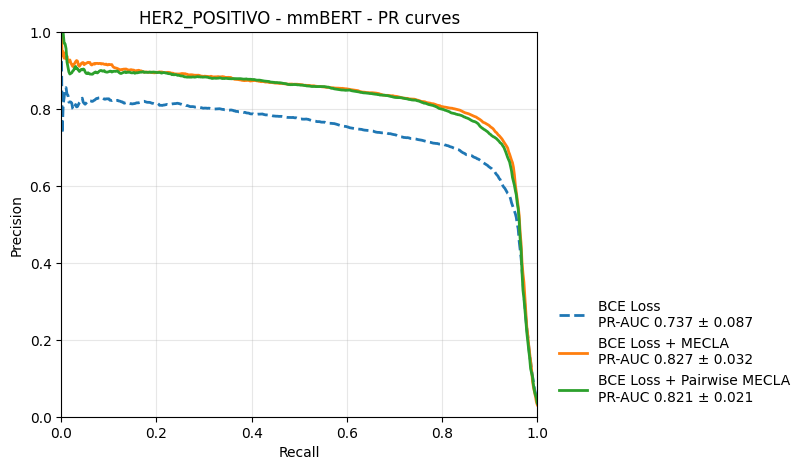

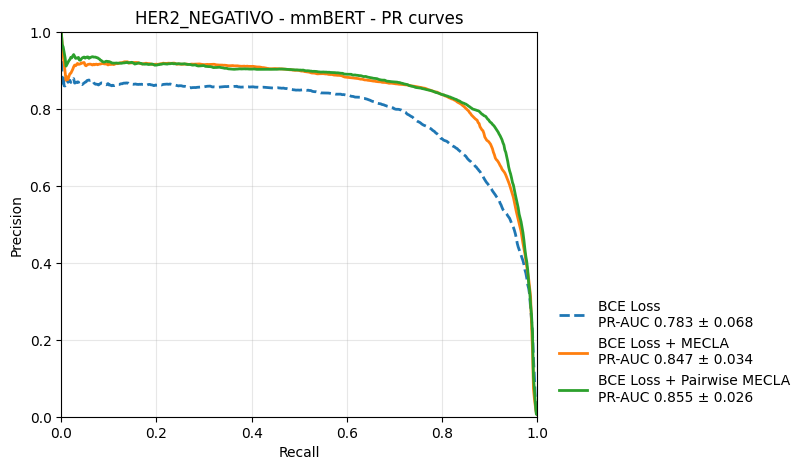

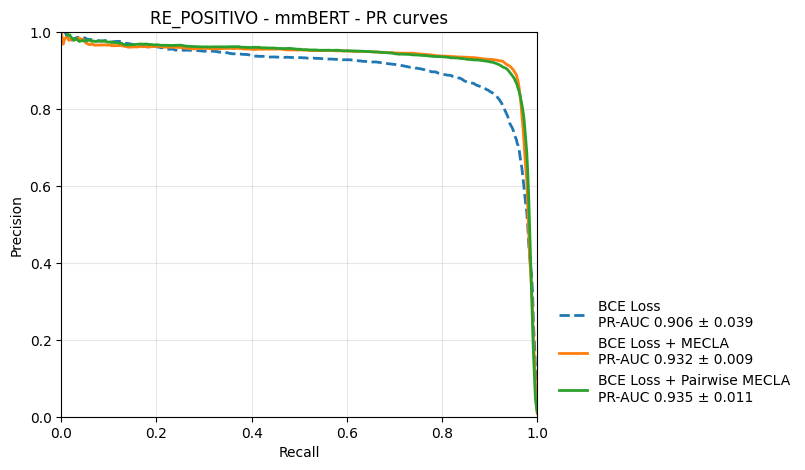

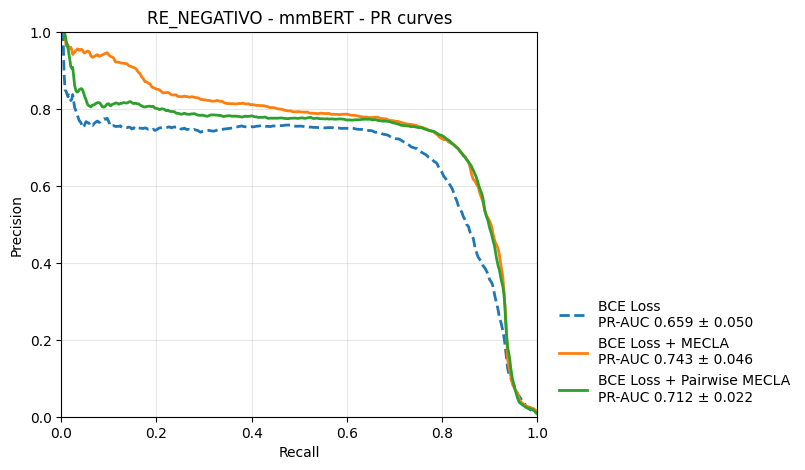

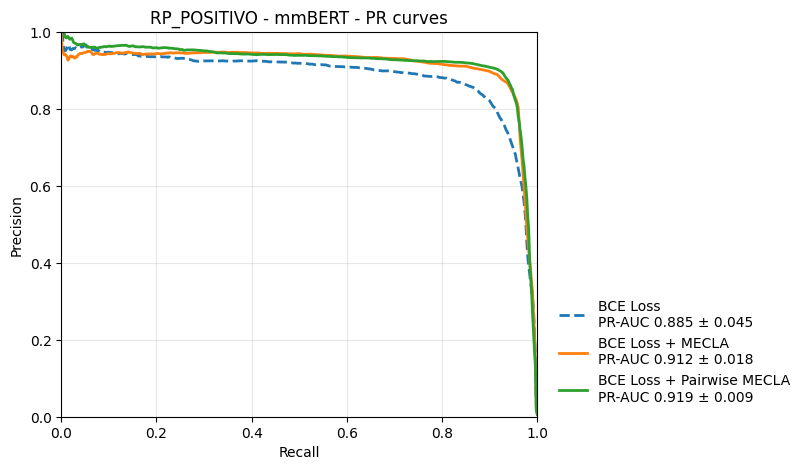

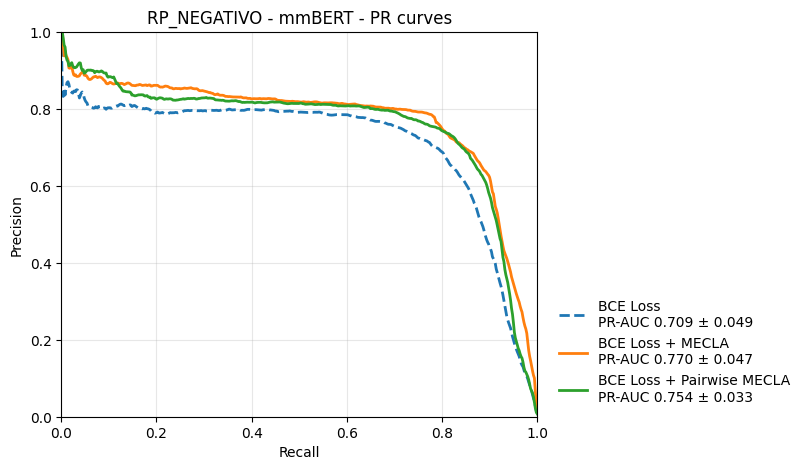

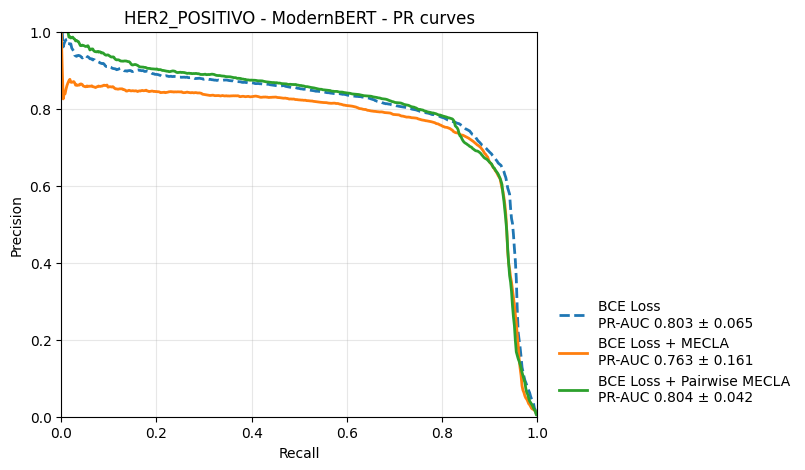

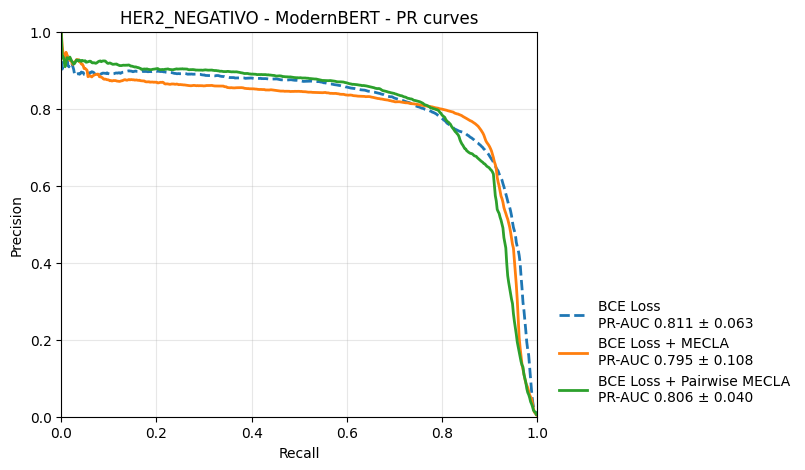

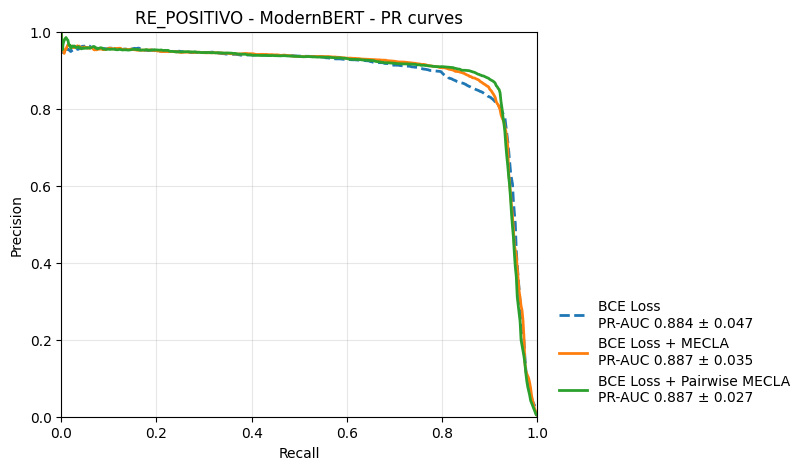

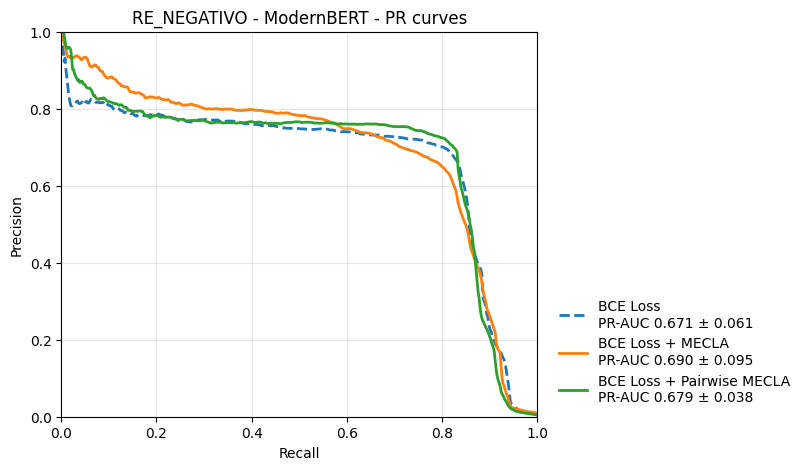

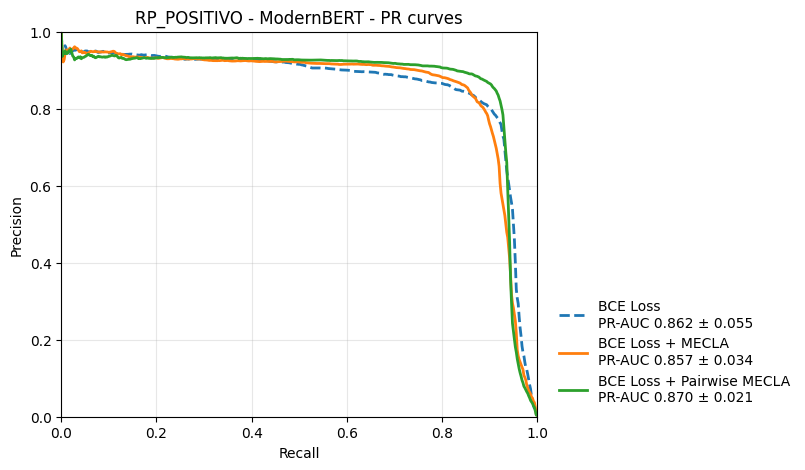

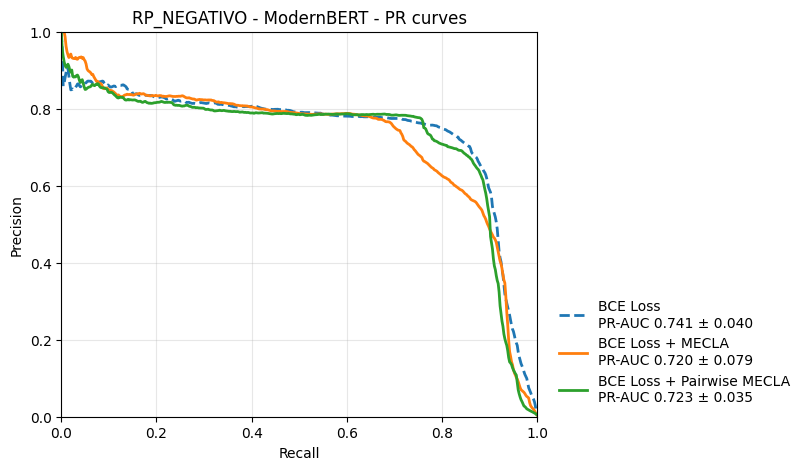

In [ ]:
from pathlib import Path
import jsonlines
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Overlapping plots

labels = ['HER2_POSITIVO', 'HER2_NEGATIVO', 'RE_POSITIVO', 'RE_NEGATIVO', 'RP_POSITIVO', 'RP_NEGATIVO']
groups = ['baseline', 'exp_1_mecla', 'exp_2_mecla']
models = ['mmBERT', 'ModernBERT']

# --- NEW: explicit color mapping ---
colors = {
    'baseline': 'tab:blue',
    'exp_1_mecla': 'tab:orange',
    'exp_2_mecla': 'tab:green',
}

groups_names = {
    'baseline': 'BCE Loss',
    'exp_1_mecla': 'BCE Loss + MECLA',
    'exp_2_mecla': 'BCE Loss + Pairwise MECLA'
}

legend_fontsize = 10  # <- adjust as you like

for model in models:
    for label in labels:
        fig, ax = plt.subplots(figsize=(8, 5))

        for group in groups:
            experiment_path = Path(f'experiments/{group}_{model.lower()}/metrics.jsonl')
            metrics = []

            with jsonlines.open(experiment_path) as reader:
                for obj in reader:
                    metrics.append(obj)

            df = pd.DataFrame(metrics)

            pr_aucs = np.asarray(
                [df["threshold_map"][i][label]["pr_auc"]
                 for i in range(len(df["threshold_map"]))]
            )

            curve_label = (
                f"{groups_names[group]}\n"
                f"PR-AUC {pr_aucs.mean():.3f} ± {pr_aucs.std():.3f}"
            )

            precisions = [
                df["threshold_map"][i][label]["precision"]
                for i in range(len(df["threshold_map"]))
            ]
            recalls = [
                df["threshold_map"][i][label]["recall"]
                for i in range(len(df["threshold_map"]))
            ]

            recall_grid, mean_p, lower, upper = _compute_pr_mean_std(
                precisions,
                recalls,
            )

            # --- MODIFIED plot call ---
            ax.plot(
                recall_grid,
                mean_p,
                linewidth=2,
                color=colors[group],
                label=curve_label,
                linestyle='dashed' if group == 'baseline' else 'solid',
            )

        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)

        # --- NEW: legend outside, bottom-right ---
        ax.legend(
            loc="lower left",
            bbox_to_anchor=(1.02, 0),
            fontsize=legend_fontsize,
            frameon=False,
        )

        # --- NEW: make room for legend ---
        fig.subplots_adjust(right=0.72)

        ax.set_title(f'{label} - {model} - PR curves')
        plt.show()


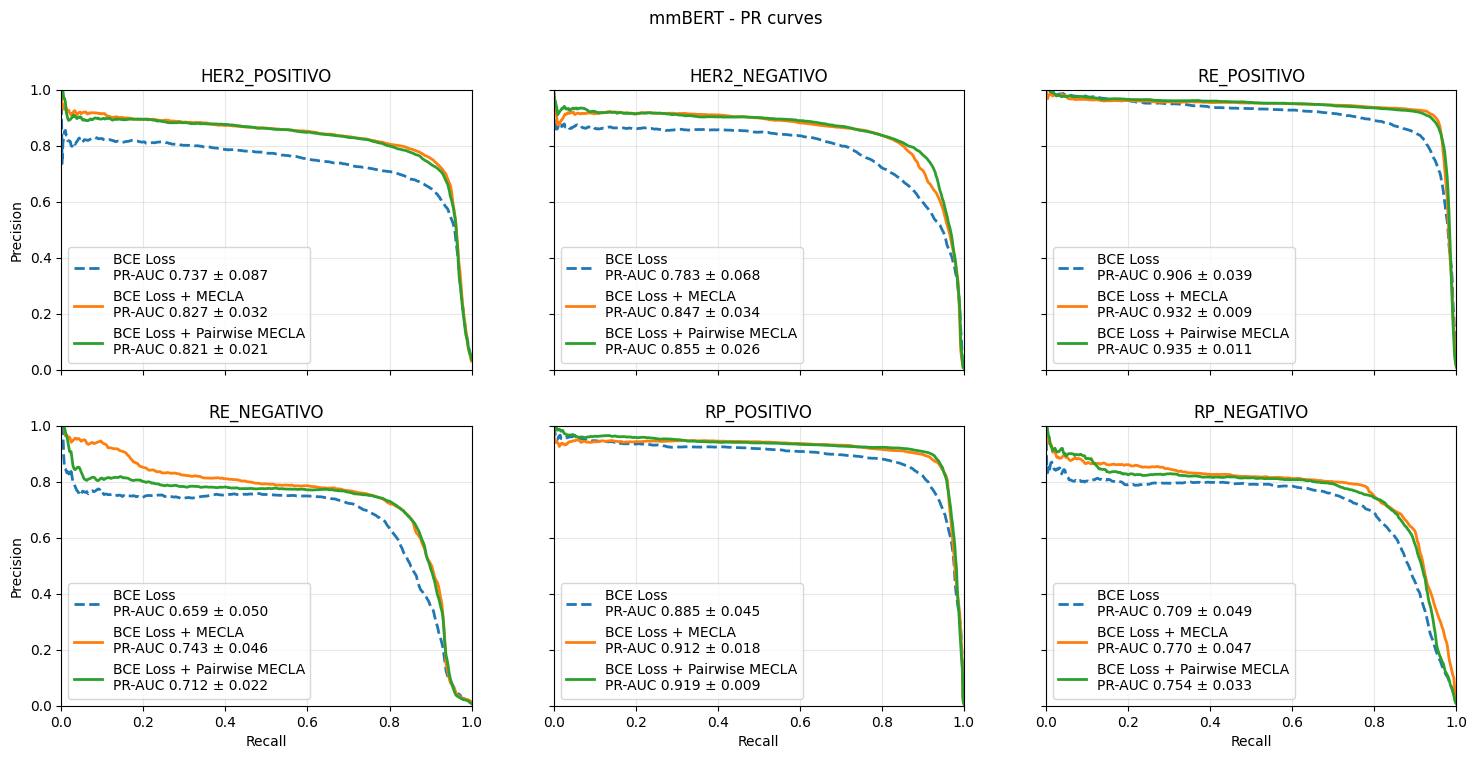

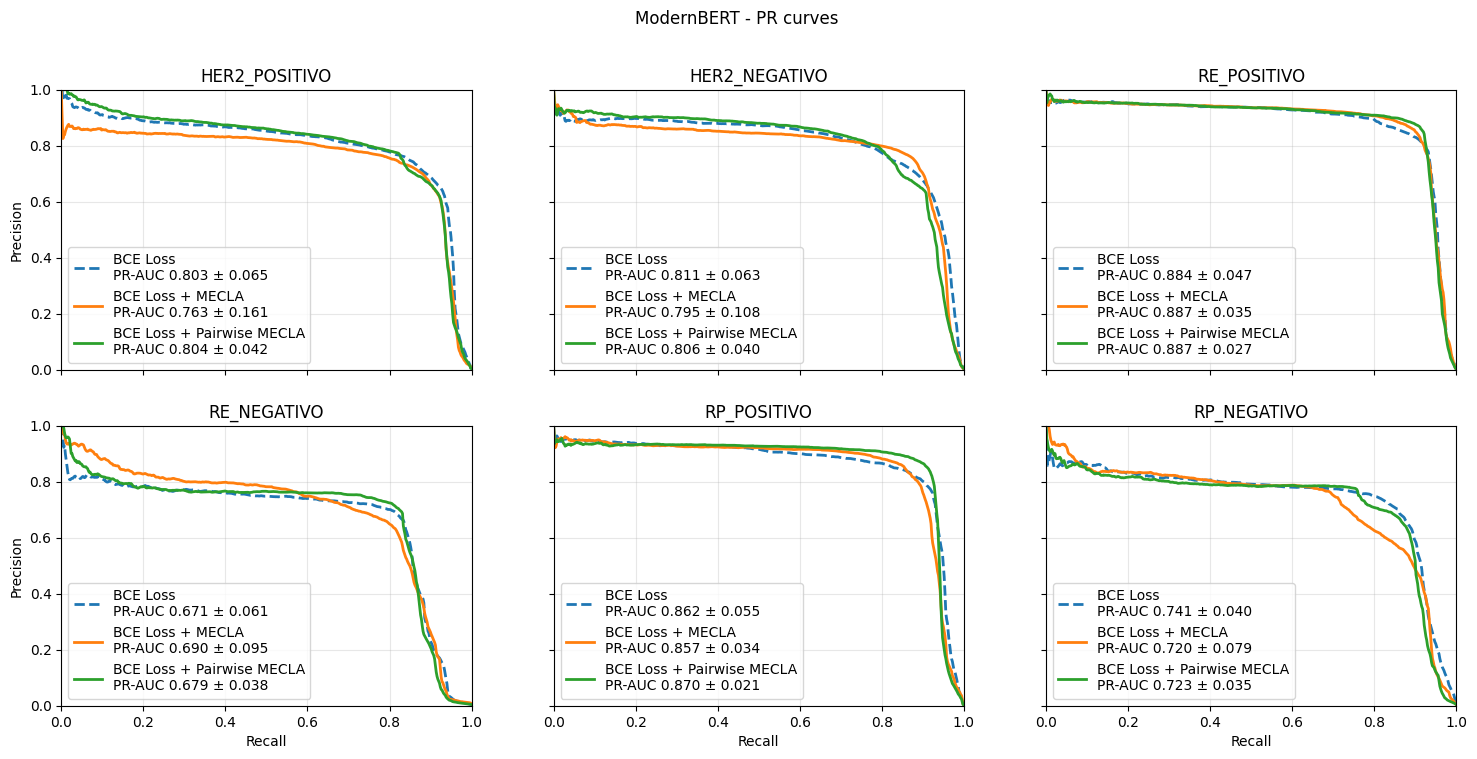

In [21]:
from pathlib import Path
import math
import jsonlines
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

labels = ['HER2_POSITIVO', 'HER2_NEGATIVO', 'RE_POSITIVO', 'RE_NEGATIVO', 'RP_POSITIVO', 'RP_NEGATIVO']
groups = ['baseline', 'exp_1_mecla', 'exp_2_mecla']
models = ['mmBERT', 'ModernBERT']

colors = {
    'baseline': 'tab:blue',
    'exp_1_mecla': 'tab:orange',
    'exp_2_mecla': 'tab:green',
}

groups_names = {
    'baseline': 'BCE Loss',
    'exp_1_mecla': 'BCE Loss + MECLA',
    'exp_2_mecla': 'BCE Loss + Pairwise MECLA'
}

line_styles = {
    'baseline': '--',
    'exp_1_mecla': '-',
    'exp_2_mecla': '-',
}

legend_fontsize = 10

MAX_COLS = 3

for model in models:
    n_labels = len(labels)
    ncols = min(MAX_COLS, n_labels)
    nrows = math.ceil(n_labels / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(6 * ncols, 4 * nrows),
        sharex=True,
        sharey=True,
    )

    # Make axes always iterable
    axes = np.array(axes).reshape(-1)

    for i, label in enumerate(labels):
        ax = axes[i]

        for group in groups:
            experiment_path = Path(f'experiments/{group}_{model.lower()}/metrics.jsonl')
            metrics = []
            with jsonlines.open(experiment_path) as reader:
                for obj in reader:
                    metrics.append(obj)

            df = pd.DataFrame(metrics)

            pr_aucs = np.asarray(
                [df["threshold_map"][j][label]["pr_auc"] for j in range(len(df["threshold_map"]))]
            )

            curve_label = (
                f"{groups_names[group]}\n"
                f"PR-AUC {pr_aucs.mean():.3f} ± {pr_aucs.std():.3f}"
            )

            precisions = [df["threshold_map"][j][label]["precision"] for j in range(len(df["threshold_map"]))]
            recalls = [df["threshold_map"][j][label]["recall"] for j in range(len(df["threshold_map"]))]

            recall_grid, mean_p, lower, upper = _compute_pr_mean_std(precisions, recalls)

            ax.plot(
                recall_grid,
                mean_p,
                linewidth=2,
                color=colors[group],
                linestyle=line_styles[group],
                label=curve_label,
            )
            ax.legend(fontsize=legend_fontsize)

        ax.set_title(label)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)

        # Only put axis labels on left/bottom to keep the grid clean
        if i % ncols == 0:
            ax.set_ylabel("Precision")
        if i // ncols == nrows - 1:
            ax.set_xlabel("Recall")

    # Turn off any unused subplots (if labels not multiple of ncols)
    for k in range(n_labels, len(axes)):
        axes[k].axis("off")


    fig.suptitle(f"{model} - PR curves", y=0.98)
    plt.show()


In [4]:
import random

random_seeds = set([random.randint(0, 1000) for _ in range(30)])
print(list(random_seeds))
print(len(random_seeds))

[387, 3, 510, 892, 658, 284, 669, 295, 552, 561, 568, 703, 200, 201, 586, 460, 77, 462, 209, 855, 730, 475, 476, 740, 741, 105, 754, 891, 508, 126]
30
